In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [216]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [217]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [218]:
df.shape

(48204, 9)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [220]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [221]:
df['holiday'].value_counts()

holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

In [222]:
df['holiday'] = df['holiday'].fillna("No Holiday")

In [223]:
df.isnull().sum()

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

In [224]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [225]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## Create New Features

In [226]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   date_time            48204 non-null  datetime64[ns]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


In [228]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

In [229]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10


In [230]:
df['day_of_week'].value_counts()
# Here 0 meens Weekday and 1 means Weekend

day_of_week
0    7072
2    6930
6    6872
1    6846
4    6836
5    6831
3    6817
Name: count, dtype: int64

In [231]:
df['day_of_week'].value_counts()

day_of_week
0    7072
2    6930
6    6872
1    6846
4    6836
5    6831
3    6817
Name: count, dtype: int64

In [232]:
# Wekend feature

df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [233]:
# Rush hour indicator

df['rush_hour'] = df['hour'].isin([8,9,10,16,17,18]).astype(int)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,is_weekend,rush_hour
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,0,1
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,0,1
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,0,0
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,0,0
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,0,0


## Visualization Map

In [234]:
hourly_traffic = df.groupby('hour')['traffic_volume'].mean().reset_index()
hourly_traffic

,hour,traffic_volume
0,0,834.781051
1,1,516.449000
2,2,388.353640
3,3,371.090864
4,4,702.551889
5,5,2094.573437
6,6,4140.503594
7,7,4740.181337
8,8,4587.497115
9,9,4385.277502


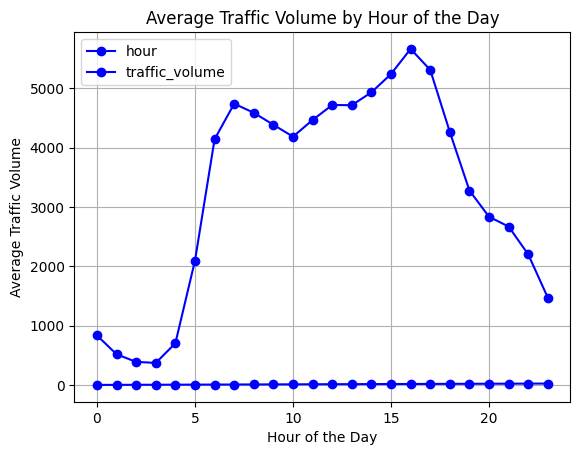

In [235]:
plt.Figure(figsize=(10,6))
hourly_traffic.plot(kind='line',marker='o',color='blue')

plt.title('Average Traffic Volume by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Traffic Volume')
plt.grid(True)
plt.show()

## Data Preprocessing 

In [236]:
df.duplicated().sum()

17

In [237]:
df = df.drop_duplicates()

In [238]:
df = df.reset_index(drop=True)

In [239]:
df.duplicated().sum()

0

In [240]:
df.shape

(48187, 14)

## Encoding 

In [241]:
from sklearn.preprocessing import OneHotEncoder

In [242]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'hour',
       'day_of_week', 'month', 'is_weekend', 'rush_hour'],
      dtype='object')

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48187 entries, 0 to 48186
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48187 non-null  object        
 1   temp                 48187 non-null  float64       
 2   rain_1h              48187 non-null  float64       
 3   snow_1h              48187 non-null  float64       
 4   clouds_all           48187 non-null  int64         
 5   weather_main         48187 non-null  object        
 6   weather_description  48187 non-null  object        
 7   date_time            48187 non-null  datetime64[ns]
 8   traffic_volume       48187 non-null  int64         
 9   hour                 48187 non-null  int32         
 10  day_of_week          48187 non-null  int32         
 11  month                48187 non-null  int32         
 12  is_weekend           48187 non-null  int64         
 13  rush_hour            48187 non-

In [244]:
obj_column = df.select_dtypes(include='object').columns
obj_column

Index(['holiday', 'weather_main', 'weather_description'], dtype='object')

In [245]:
df_encoded = pd.get_dummies(df, columns=['holiday', 'weather_main'],dtype=int,drop_first=True)
df_encoded.head()

,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,hour,day_of_week,month,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,...,1,0,0,0,0,0,0,0,0,0
1,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,10,1,10,...,1,0,0,0,0,0,0,0,0,0
2,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,...,1,0,0,0,0,0,0,0,0,0
3,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,...,1,0,0,0,0,0,0,0,0,0
4,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,13,1,10,...,1,0,0,0,0,0,0,0,0,0


In [246]:
df = df.sort_values(by='date_time').reset_index(drop=True)

In [247]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,is_weekend,rush_hour
0,No Holiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,0,1
1,No Holiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,0,1
2,No Holiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,0,0
3,No Holiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,0,0
4,No Holiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,0,0


In [248]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [249]:
from sklearn.ensemble import RandomForestRegressor

In [250]:
model = RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=-1)

In [251]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'hour',
       'day_of_week', 'month', 'is_weekend', 'rush_hour'],
      dtype='object')

In [252]:
features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "rush_hour",
    "holiday",
    "weather_main"
]

X = df[features]
y = df["traffic_volume"]

In [253]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [254]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["holiday", "weather_main"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [255]:
model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [272]:
y_pred = model.predict(X_test_processed)
y_pred

array([2484.09, 2354.84, 2410.12, ..., 2199.29, 1666.68, 1040.04])

## Compare Actual and Predicted Value

In [274]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison.head()

,Actual,Predicted
38549,2704,2484.09
38550,2704,2354.84
38551,2704,2410.12
38552,2204,2532.45
38553,2204,2427.62


In [258]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [259]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)*100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 308.96
Mean Squared Error (MSE): 297799.98
Root Mean Squared Error (RMSE): 545.71
R-squared (R2): 92.31


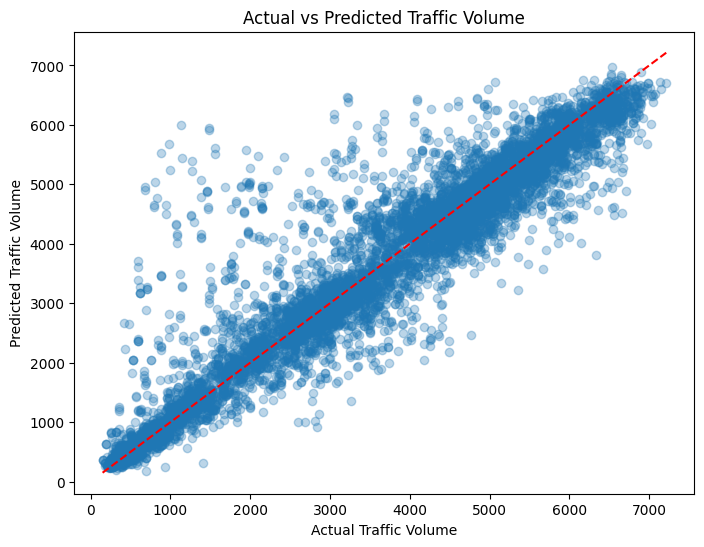

In [260]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()

## Model interpretation and improvement

In [261]:
feature_name = preprocessor.get_feature_names_out()

importances_df = pd.DataFrame({
    "feature" : feature_name,
    "importance" : model.feature_importances_
})

importances_df = importances_df.sort_values(by="importance", ascending=False)

print(importances_df)

                                   feature    importance
27                         remainder__hour  8.261683e-01
28                  remainder__day_of_week  5.799222e-02
30                   remainder__is_weekend  5.224779e-02
23                         remainder__temp  3.385679e-02
29                        remainder__month  1.062507e-02
26                   remainder__clouds_all  7.031312e-03
31                    remainder__rush_hour  3.062437e-03
24                      remainder__rain_1h  2.930441e-03
13                cat__weather_main_Clouds  2.029971e-03
12                 cat__weather_main_Clear  8.302278e-04
17                  cat__weather_main_Mist  7.632616e-04
20                  cat__weather_main_Snow  5.932054e-04
18                  cat__weather_main_Rain  5.063880e-04
16                  cat__weather_main_Haze  4.925720e-04
15                   cat__weather_main_Fog  2.907787e-04
22          cat__weather_main_Thunderstorm  2.193563e-04
25                      remaind

In [262]:
from sklearn.metrics import r2_score,mean_absolute_error

y_train_pred = model.predict(X_train_processed)

y_test_pred = model.predict(X_test_processed)

print("Training r2:", r2_score(y_train, y_train_pred)*100)
print("Testing r2:", r2_score(y_test, y_test_pred)*100)

print("Training MAE:", mean_absolute_error(y_train, y_train_pred))
print("Testing MAE:", mean_absolute_error(y_test, y_test_pred))

Training r2: 99.28578145366902
Testing r2: 92.30778426672079
Training MAE: 91.72783743695408
Testing MAE: 308.9620898576073


In [263]:
from sklearn.ensemble import RandomForestRegressor

model_tuned = RandomForestRegressor(
    n_estimators=100,
    max_depth=20, #limits how deep each tree can grow.
    min_samples_leaf=5, #requires at least five training records in each leaf.
    random_state=42,
    n_jobs=-1
)

model_tuned.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [264]:
from sklearn.metrics import r2_score, mean_absolute_error

y_train_tuned = model_tuned.predict(X_train_processed)
y_test_tuned = model_tuned.predict(X_test_processed)

print("Training R2:", r2_score(y_train, y_train_tuned))
print("Testing R2:", r2_score(y_test, y_test_tuned))

print("Training MAE:", mean_absolute_error(y_train, y_train_tuned))
print("Testing MAE:", mean_absolute_error(y_test, y_test_tuned))

Training R2: 0.9688506161094348
Testing R2: 0.9286819146541538
Training MAE: 193.94564994718758
Testing MAE: 292.4431511847103


In [265]:
from sklearn.metrics import mean_squared_error
import numpy as np

original_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_tuned)
)

print("Original RMSE:", original_rmse)
print("Tuned RMSE:", tuned_rmse)

Original RMSE: 545.7105304122659
Tuned RMSE: 525.4561071906112


## Save Model

In [266]:
import joblib

joblib.dump(model_tuned, "traffic_volume_model.pkl")

joblib.dump(preprocessor, "preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [267]:
import joblib
import pandas as pd

# Load saved model and preprocessor
loaded_model = joblib.load("traffic_volume_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

# Create new traffic input
new_traffic = pd.DataFrame([{
    "temp": 300.15,
    "rain_1h": 0.0,
    "snow_1h": 0.0,
    "clouds_all": 40,
    "hour": 17,
    "day_of_week": 1,
    "month": 10,
    "is_weekend": 0,
    "rush_hour": 1,
    "holiday": "None",
    "weather_main": "Clouds"
}])

# Apply preprocessing
new_traffic_processed = loaded_preprocessor.transform(new_traffic)

# Predict traffic volume
prediction = loaded_model.predict(new_traffic_processed)

print("Predicted Traffic Volume:", round(prediction[0]))

Predicted Traffic Volume: 6157


In [268]:
print(df["traffic_volume"].describe())

print("\nTraffic volume percentiles:")
print(df["traffic_volume"].quantile([0.25, 0.50, 0.75]))

count    48187.000000
mean      3259.618134
std       1986.954465
min          0.000000
25%       1192.500000
50%       3379.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

Traffic volume percentiles:
0.25    1192.5
0.50    3379.0
0.75    4933.0
Name: traffic_volume, dtype: float64


In [269]:
def classify_traffic(volume):
    if volume <= 1192.5:
        return "Low"
    elif volume <= 3379:
        return "Moderate"
    elif volume <= 4933:
        return "High"
    else:
        return "Very High"

# Add traffic category to the dataset
df["traffic_level"] = df["traffic_volume"].apply(classify_traffic)

# Check category counts
print(df["traffic_level"].value_counts())

traffic_level
High         12054
Moderate     12049
Low          12047
Very High    12037
Name: count, dtype: int64


In [277]:
predicted_level = classify_traffic(prediction[0])

print("Predicted Traffic Volume:", round(prediction[0]))
print("Traffic Category:", predicted_level)

Predicted Traffic Volume: 6157
Traffic Category: Very High


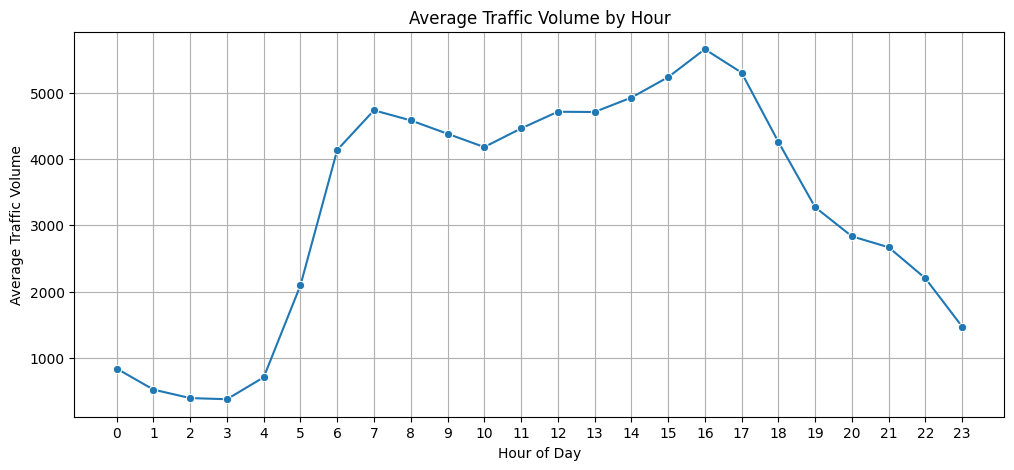

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average traffic for each hour
hourly_traffic = df.groupby("hour")["traffic_volume"].mean()

# Plot hourly traffic
plt.figure(figsize=(12, 5))
sns.lineplot(x=hourly_traffic.index, y=hourly_traffic.values, marker="o")

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

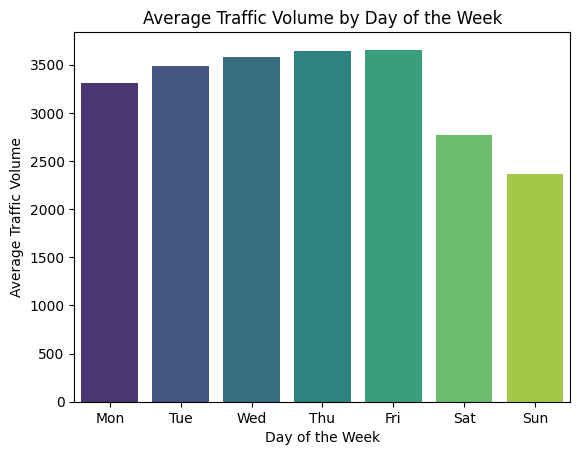

In [282]:
import seaborn as sns
daily_traffic = df.groupby("day_of_week")["traffic_volume"].mean()

plt.Figure(figsize=(10,6))

sns.barplot(x=daily_traffic.index, y=daily_traffic.values, palette="viridis")

plt.title("Average Traffic Volume by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Traffic Volume")

plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

## Average traffic by weather

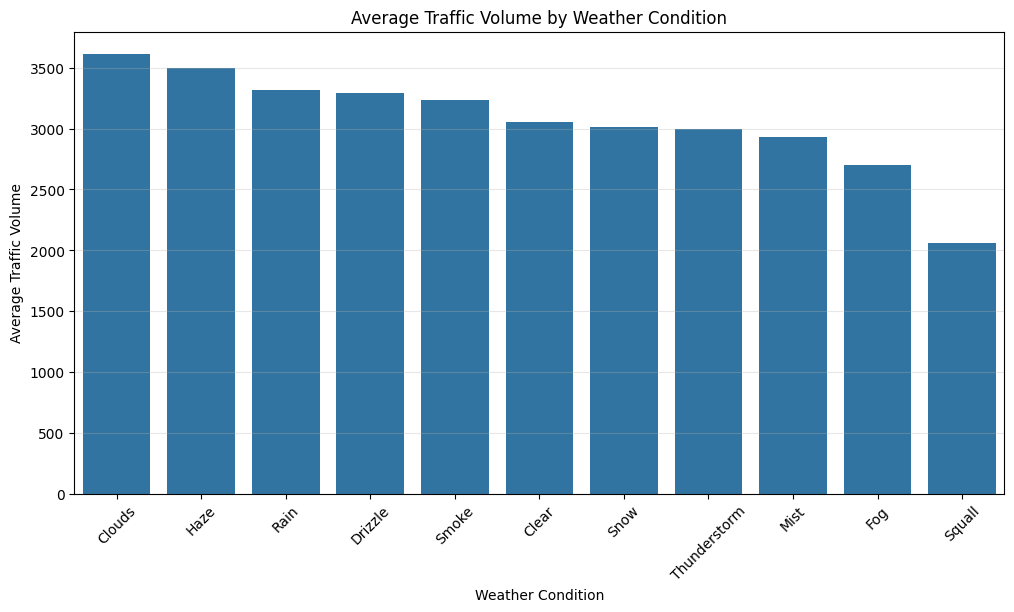

In [283]:
weather_traffic = df.groupby("weather_main")["traffic_volume"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=weather_traffic.index,
    y=weather_traffic.values
)

plt.title("Average Traffic Volume by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Traffic Volume")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

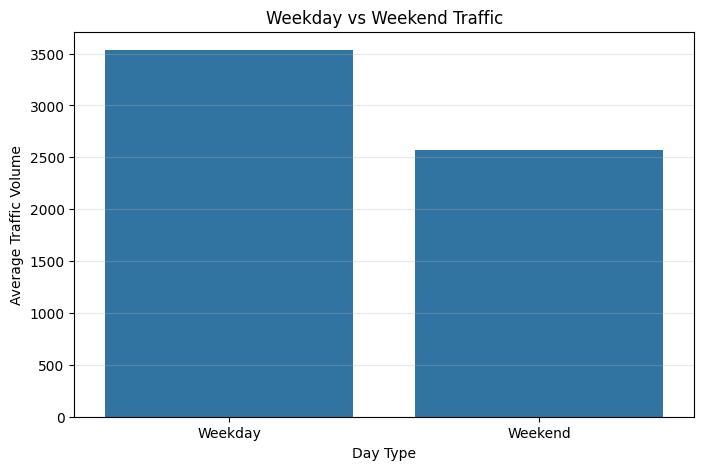

Weekday    3533.291791
Weekend    2570.699635
Name: traffic_volume, dtype: float64


In [284]:
weekend_traffic = df.groupby("is_weekend")["traffic_volume"].mean()

weekend_traffic.index = ["Weekday", "Weekend"]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=weekend_traffic.index,
    y=weekend_traffic.values
)

plt.title("Weekday vs Weekend Traffic")
plt.xlabel("Day Type")
plt.ylabel("Average Traffic Volume")
plt.grid(axis="y", alpha=0.3)

plt.show()
print(weekend_traffic)

## Traffic volume distribution (Histogram)

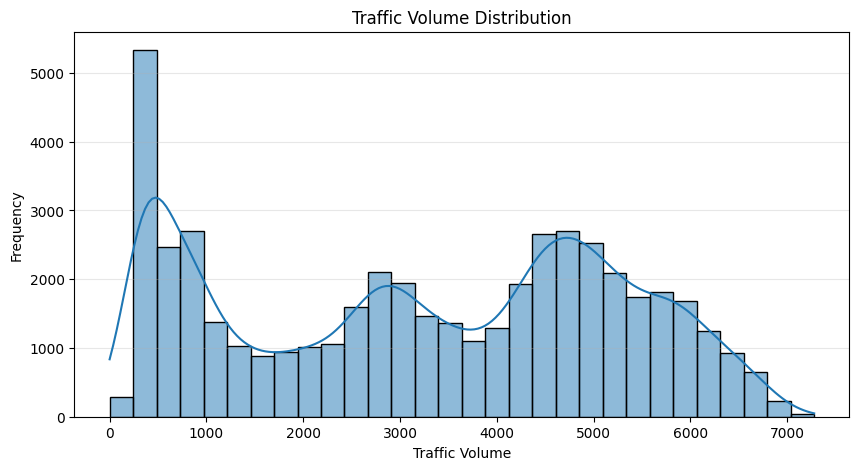

In [285]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="traffic_volume",
    bins=30,
    kde=True
)

plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.show()

## Correlation heatmap

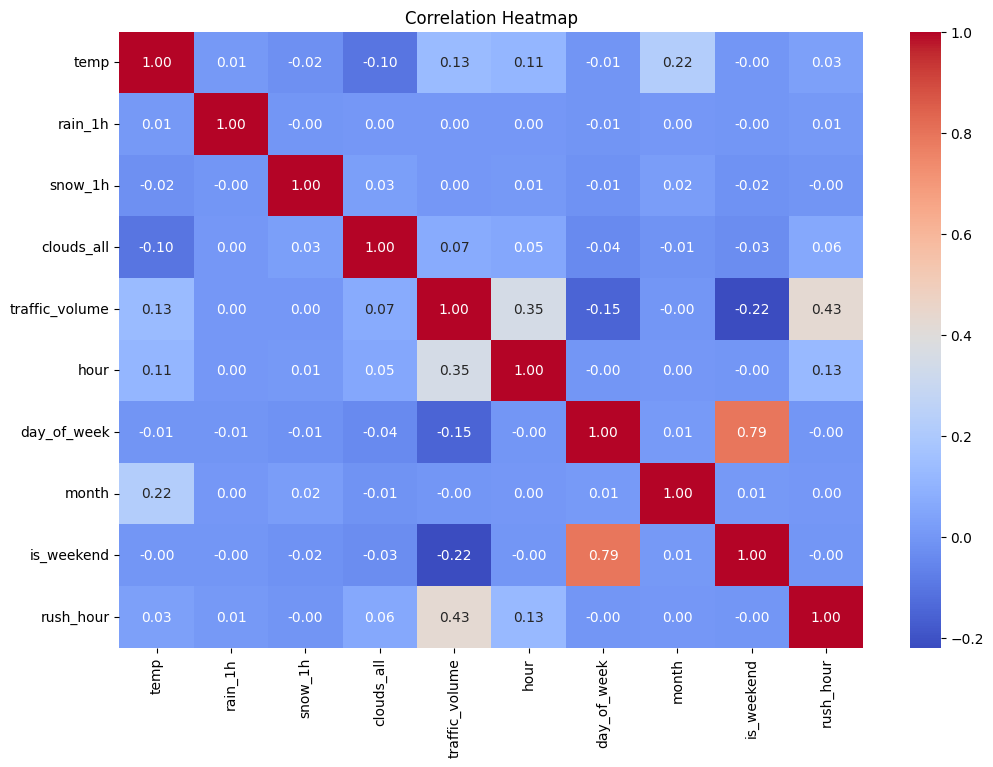

In [286]:
numerical_df = df.select_dtypes(include=["number"])

correlation = numerical_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Actual vs Predicted Traffic

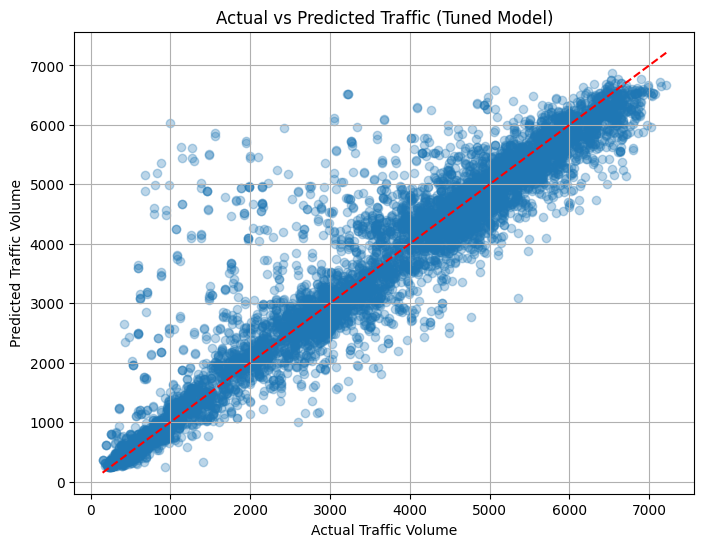

In [287]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_tuned,
    alpha=0.3
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic (Tuned Model)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.grid(True)
plt.show()

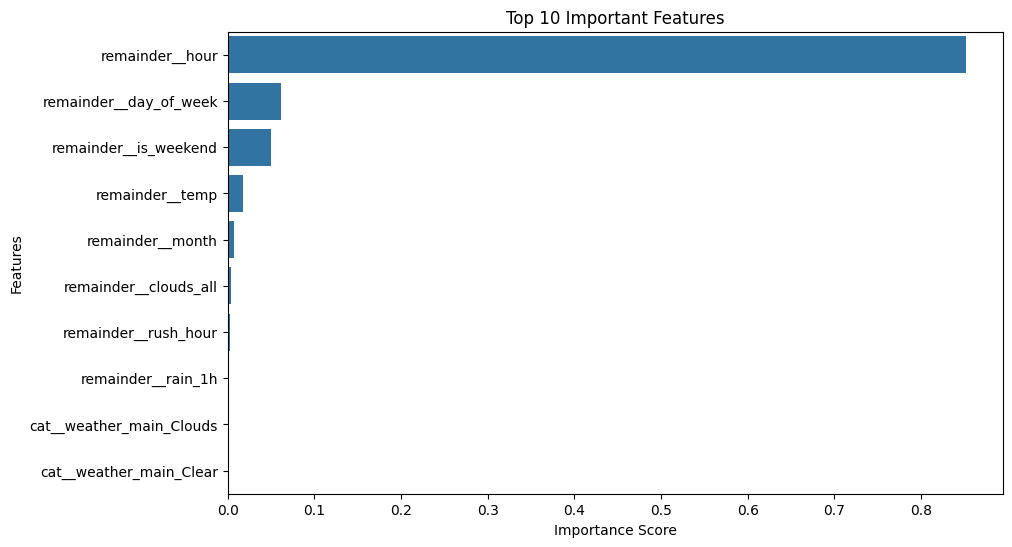

In [288]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = model_tuned.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()